# 02 — The flux-anchored method, step by step

Notebook 03 solves the model to periodic steady state **58 times per site**. By
brute force — marching the heat equation for ~1000 lunar cycles until the deep
column stops drifting — that would take the better part of a day, and the naive
"has it converged?" test *lies*: the surface skin settles in ~10 cycles while the
metre-deep column is still tens of kelvin off.

This notebook builds the fix — the **flux-anchored method** — in three moves:

1. **The problem** — why brute force is slow and its stop-test is unreliable.
2. **The method** — the two-stage anchor solve, animated phase by phase.
3. **The proof** — it reaches the *same* steady state from any start, ~21× faster,
   and certifies its own convergence.

Then we read temperatures off the converged cycle. Every number below comes from
the live code and `results/` — nothing is typed in by hand.

In [1]:
# --- setup: repo, the retrieved K_d, the grid + forcing ------------------------
import functools, json, time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image

from lunar._bootstrap import find_repo_root
CODE = find_repo_root()                       # .../Lunar-Clean/code
ANIM = CODE.parent / "figures" / "anim"       # pre-generated animations live here

from lunar.config import SITES, GRID, HAYNE, DT_STEP
from lunar.grid import make_geometric_grid
from lunar.properties import conductivity_hayne, specific_heat
from lunar.solver import standard_insolation, periodic_time_grid
from lunar.equilibrium import (solve_periodic_equilibrium,
                               profile_at_time, profile_at_local_time)

SITE = SITES["A15"]

# read the retrieved K_d* straight from the results JSON -- never hardcode it
res = json.loads((CODE / "results" / "kd_retrieval_results.json").read_text())
KD  = res["A15"]["kd_star"]            # W m^-1 K^-1
Z0  = 0.55                             # anchor depth [m]

# build the depth grid + one lunation of forcing (shared by every solve below)
grid  = make_geometric_grid(**GRID)
t     = periodic_time_grid(DT_STEP)
insol = standard_insolation(SITE["lat"], t)
K_func  = functools.partial(conductivity_hayne, Ks=HAYNE["K_S"], Kd=KD,
                            H=HAYNE["H"], chi=HAYNE["CHI"])
cp_func = functools.partial(specific_heat, model="hayne")

print(f"Apollo 15   K_d* = {KD*1e3:.3f} mW/m/K   (from results/kd_retrieval_results.json)")
print(f"            Q_b  = {SITE['Q_BASAL']*1e3:.0f} mW/m^2    anchor z0 = {Z0} m")
print(f"            grid = {grid.z_mid.size} cells to {grid.z_mid[-1]:.2f} m")

Apollo 15   K_d* = 4.600 mW/m/K   (from results/kd_retrieval_results.json)
            Q_b  = 21 mW/m^2    anchor z0 = 0.55 m
            grid = 69 cells to 4.85 m


## 1. The problem — brute force is slow, and its stop-test lies

Start the column at a wrong, flat temperature and march it forward one lunar
cycle at a time. Heat diffuses **down** from the surface:

- The **skin** (top ~0.5 m) settles within ~10 cycles — it is thin.
- The **deep column** keeps creeping for ~1000 cycles — heat must diffuse through
  metres of low-conductivity regolith.

The right panel tracks the temperature at 1 m. The old code stopped at **30
cycles** — where the cycle-to-cycle change merely *looked* small — and declared
victory while still kelvins from the truth. That is the bug the anchor method
was built to kill.

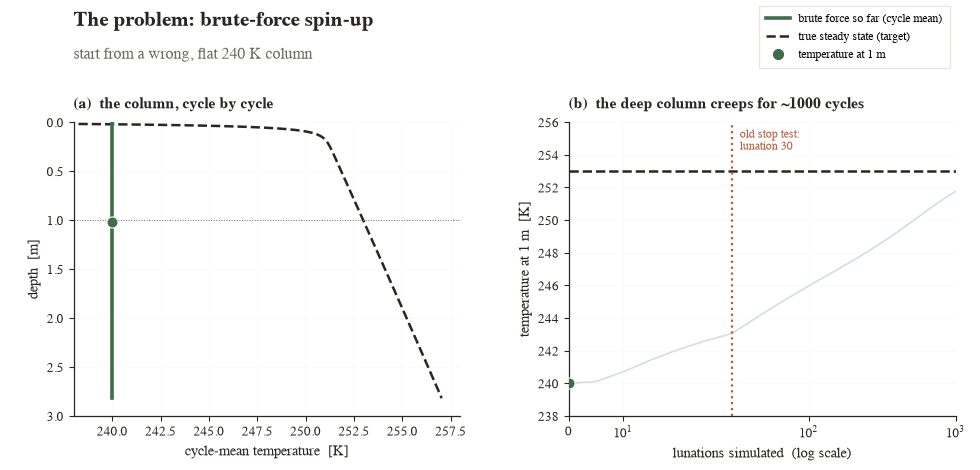

In [2]:
# pre-generated by pipeline/figures/make_spinup_animation.py
Image(filename=str(ANIM / "spinup.gif"))

## 2. The method — anchor the deep column instead of waiting for it

The insight: in steady state the *same* heat flux $Q_b$ passes through every
layer, so the mean gradient at each depth is **fixed** by

$$\frac{d\langle T\rangle}{dz}=\frac{Q_b-u_{\rm rect}}{K(\langle T\rangle,z)}.$$

We don't have to *wait* for the deep column to relax — we can *compute* what it
must be. Below ~0.5 m the eddy term $u_{\rm rect}\to 0$, so the gradient is simply
$Q_b/K$. The animation walks the whole two-stage solve, phase by phase:

1. **Rough guess** — skin and deep both wrong.
2. **Step A** — time-step *only* the skin (a thin, fast column) to its cycle mean.
3. **Read the anchor** — $\langle T\rangle(z_0)$ at $z_0=0.55$ m, below the wave.
4. **Step B** — from the anchor, *walk down*, adding $(Q_b/K)\,\Delta z$ node by
   node. No time-stepping — it computes the profile the physics demands.
5. **Repeat A ↔ B** — the corrected deep profile shifts the skin slightly; iterate.
6. **Converged** — the anchor stops moving (drift < 0.005 K). This *is* the
   periodic steady state.

The right panel is the **real** per-cycle anchor drift, contracting geometrically
to the tolerance. *(The animation uses a reduced inner-sweep count so the A ↔ B
iteration is visible; production settings reach the same profile in ~2 outer
cycles.)*

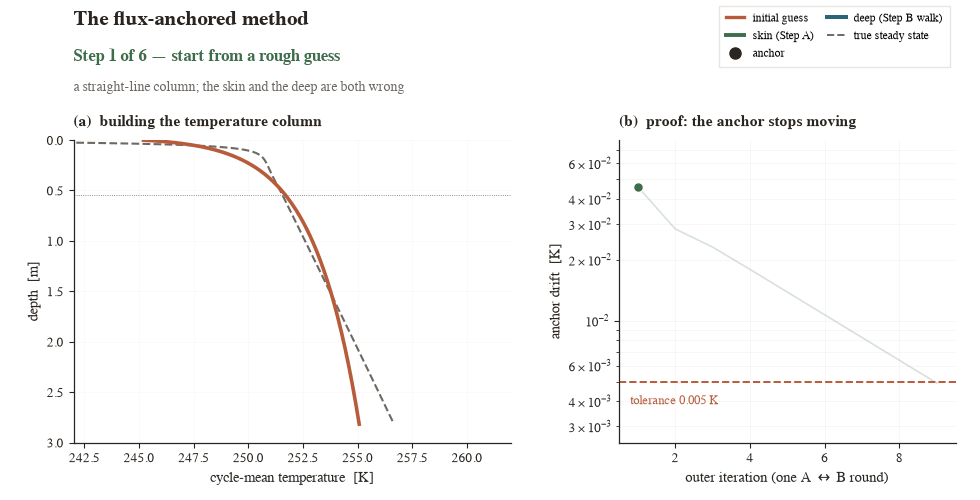

In [3]:
# pre-generated by pipeline/figures/make_anchor_method_animation.py
Image(filename=str(ANIM / "anchor_method_steps.gif"))

## 3. The proof — fast, and the *right* answer

Two things to verify. **Fast:** run it live and let it certify itself (anchor
drift, flux closure). **Right:** the answer must not depend on where you start,
and it must match what brute force reaches the slow way — and Section 1 already
showed the brute-force line creeping onto this very target ($T(1\,\mathrm{m})
\approx 253$ K). First, one live solve:

In [4]:
# Passing hayne_params uses the compiled (Numba) march -- identical to the
# generic K_func path to <1e-9 K (see notebook 06), just faster.
t0 = time.perf_counter()
eq = solve_periodic_equilibrium(
        grid=grid, t=t, insolation=insol, albedo=SITE["albedo"],
        emissivity=SITE["emissivity"], Q_b=SITE["Q_BASAL"],
        K_func=K_func, cp_func=cp_func, T_guess=SITE["T_MEAN_EFF"],
        hayne_params=(HAYNE["K_S"], KD, HAYNE["H"], HAYNE["CHI"]))
dt = time.perf_counter() - t0

print(f"flux-anchored solve : {dt:.2f} s   ({eq.n_outer} outer iterations)")
print(f"  anchor drift = {eq.anchor_drift_K*1e3:6.2f} mK   (tolerance 5.00 mK)")
print(f"  flux closure = {eq.flux_closure*100:6.2f} %")
print(f"  converged    = {eq.converged}")
print()
print("The same steady state by brute force takes ~1570 s. At the SAME backend")
print("that is ~21x fewer solver-cycles (results/speedup_benchmark.json:")
print("74.7 s vs 1567.7 s, generic Python); the compiled march here is faster still.")

flux-anchored solve : 0.96 s   (4 outer iterations)
  anchor drift =   0.37 mK   (tolerance 5.00 mK)
  flux closure =   0.24 %
  converged    = True

The same steady state by brute force takes ~1570 s. At the SAME backend
that is ~21x fewer solver-cycles (results/speedup_benchmark.json:
74.7 s vs 1567.7 s, generic Python); the compiled march here is faster still.


And it lands on the **same** state no matter where you start — the property the
old brute-force stop-test failed to guarantee. Solve from three wildly different
initial temperatures and compare:

In [5]:
import itertools
profiles = {}
for guess in (200.0, 250.0, 300.0):
    e = solve_periodic_equilibrium(
            grid=grid, t=t, insolation=insol, albedo=SITE["albedo"],
            emissivity=SITE["emissivity"], Q_b=SITE["Q_BASAL"],
            K_func=K_func, cp_func=cp_func, T_guess=guess,
            hayne_params=(HAYNE["K_S"], KD, HAYNE["H"], HAYNE["CHI"]))
    profiles[guess] = e.T_mean

maxdiff = max(np.max(np.abs(profiles[a] - profiles[b]))
              for a, b in itertools.combinations(profiles, 2))
print(f"starts 200, 250, 300 K  ->  max profile difference = {maxdiff*1e3:.3f} mK")
print("the converged steady state is independent of the initial guess.")
print("(Section 1 showed brute force reaching this same target the slow way:")
print(" two independent methods, one answer.)")

starts 200, 250, 300 K  ->  max profile difference = 0.000 mK
the converged steady state is independent of the initial guess.
(Section 1 showed brute force reaching this same target the slow way:
 two independent methods, one answer.)


## 4. The converged cycle is a usable object

`solve_periodic_equilibrium` doesn't just return a mean profile — it stores the
full periodic cycle. So you can read the instantaneous $T(z)$ at any phase of the
lunar day with **no re-solve**, straight off `eq`. Notice only the skin moves;
below ~0.5 m every phase collapses onto the cycle mean — the very fact the anchor
method exploits.

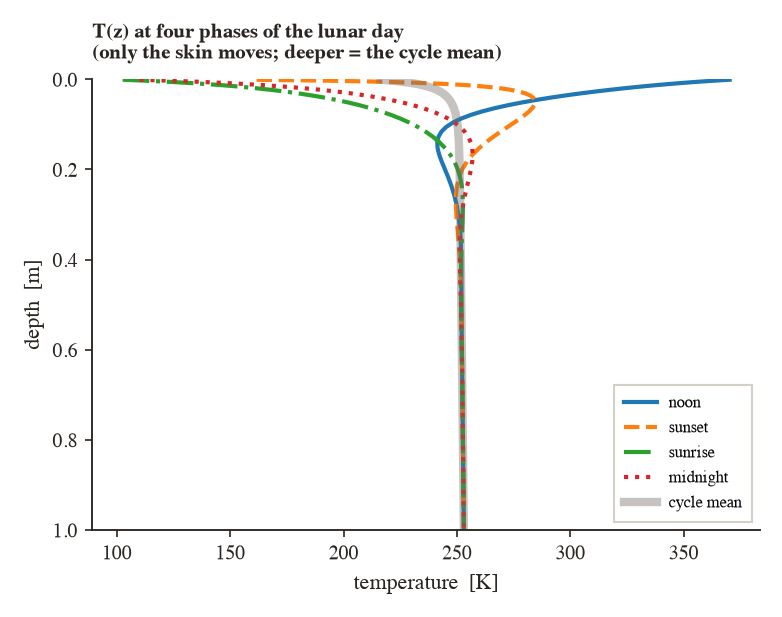

surface T at 14:30 local lunar time = 351.6 K


In [6]:
from lunar.plotting.style import C_DIM
zt = eq.out.z
fig, ax = plt.subplots(figsize=(5.0, 3.9), constrained_layout=True)
for phase, ls in [("noon", "-"), ("sunset", "--"),
                  ("sunrise", "-."), ("midnight", ":")]:
    ax.plot(profile_at_time(eq, phase), zt, ls, lw=2, label=phase)
ax.plot(eq.T_mean, grid.z_mid, color=C_DIM, lw=4, alpha=0.4, label="cycle mean")
ax.set_ylim(1.0, 0.0)          # top 1 m: the skin fans out, then collapses onto the mean
ax.set_xlabel("temperature  [K]"); ax.set_ylabel("depth  [m]")
ax.set_title("T(z) at four phases of the lunar day\n(only the skin moves; deeper = the cycle mean)",
             loc="left", fontsize=10)
ax.legend(fontsize=8, loc="lower right")
plt.show()

# or just name a time on a 24-hour lunar clock:
T_afternoon = profile_at_local_time(eq, "14:30")
print(f"surface T at 14:30 local lunar time = {T_afternoon[0]:.1f} K")

## 📎 Code this notebook uses

| Step | Code |
|---|---|
| the anchor solver (Step A + Step B + outer loop) | `lunar.equilibrium.solve_periodic_equilibrium` |
| Step B slope walk $d\langle T\rangle/dz=(Q_b-u_{\rm rect})/K$ | `lunar.equilibrium._reconstruct_subskin`, `_rectified_flux` |
| read T(z) off the converged cycle | `lunar.equilibrium.profile_at_time` / `profile_at_local_time` |
| the animations | `pipeline/figures/make_spinup_animation.py`, `make_anchor_method_animation.py` |
| the overlay proof | `pipeline/figures/make_equilibrium_demo.py` |

For the file-by-file reference, open **`CODE_MANUAL.pdf`**. Next: **`03_retrieval.ipynb`**
runs this exact solver 58× to retrieve $K_d$.